# XGBoost classifier Notebook


Dataset:
LendingClub Loan Data (CSV) https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv?select=loan.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
use_cols = [
    "loan_status",
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "grade",
    "open_acc",
    "revol_util",
    "earliest_cr_line",
    "issue_d"
]
    

data = pd.read_csv(r"C:\Users\thany\Downloads\loan.csv\loan.csv", usecols=use_cols)

In [3]:
data.head()

,loan_amnt,term,int_rate,installment,grade,annual_inc,issue_d,loan_status,dti,earliest_cr_line,open_acc,revol_util
0,2500,36 months,13.56,84.92,C,55000.0,Dec-2018,Current,18.24,Apr-2001,9.0,10.3
1,30000,60 months,18.94,777.23,D,90000.0,Dec-2018,Current,26.52,Jun-1987,13.0,24.2
2,5000,36 months,17.97,180.69,D,59280.0,Dec-2018,Current,10.51,Apr-2011,8.0,19.1
3,4000,36 months,18.94,146.51,D,92000.0,Dec-2018,Current,16.74,Feb-2006,10.0,78.1
4,30000,60 months,16.14,731.78,C,57250.0,Dec-2018,Current,26.35,Dec-2000,12.0,3.6


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   loan_amnt         int64  
 1   term              object 
 2   int_rate          float64
 3   installment       float64
 4   grade             object 
 5   annual_inc        float64
 6   issue_d           object 
 7   loan_status       object 
 8   dti               float64
 9   earliest_cr_line  object 
 10  open_acc          float64
 11  revol_util        float64
dtypes: float64(6), int64(1), object(5)
memory usage: 207.0+ MB


In [5]:
print(data["loan_status"].value_counts())

print("Here we see the statuses of the loans of the clients.")

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64
Here we see the statuses of the loans of the clients.


<div style="
    font-size: 14px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    The original dataset was very large and contained a lot of information that we do not need for this model so we have trimmed it down for better loading speed and cleaner reading. It initially had 145 columns, we have selected eleven of the ones we need. 5 of the 11 columns contains float entries, that is decimal point numbers. 2 of the columns have integer values and 4 of them are objects. We have also trimmed the dataset to just the first 1,000,000 entries to train and test our model with.
</div>

In [6]:
# We will create a new column Crediy History Years from the object column earliest_cr_line.

data["earliest_cr_line"] = pd.to_datetime(data["earliest_cr_line"], format="%b-%Y", errors="coerce")
data["issue_d"] = pd.to_datetime(data["issue_d"], format="%b-%Y", errors="coerce")

data["credit_history_years"] = (data['issue_d'] - data["earliest_cr_line"]).dt.days/365

data["credit_history_years"] = data["credit_history_years"].round(1)

In [7]:
# We first create a column of defaulted and paid off loans from clients
data = data[data["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
data.loc[:, "default"] = data["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})


In [8]:
data[["credit_history_years", "default"]].head()
data["credit_history_years"].describe()

count    1.303607e+06
mean     1.626357e+01
std      7.498408e+00
min      3.000000e+00
25%      1.130000e+01
50%      1.480000e+01
75%      2.000000e+01
max      8.330000e+01
Name: credit_history_years, dtype: float64

In [9]:
# The cell below produced a ValueError at first so we are making a minor change to fix that

data["term"] = (
    data["term"].astype(str).str.extract(r"(\d+)").astype(int))

<div style="
    font-size: 16px;
    font-weight: bold;
    padding: 6px;
    border-radius: 5px;
    margin: 10px 0;
">
    Now we will encode some features and also split the dataset into what we'll use to train and what we'll use to test the model. 
</div>

In [10]:
data = data.sample(n = len(data), random_state=42)

In [11]:
Y = data["default"].values
X = data.loc[:, ~data.columns.isin(["default", 'loan_status'])]

In [12]:
X.dtypes, Y.shape # Confirmation

(loan_amnt                        int64
 term                             int64
 int_rate                       float64
 installment                    float64
 grade                           object
 annual_inc                     float64
 issue_d                 datetime64[ns]
 dti                            float64
 earliest_cr_line        datetime64[ns]
 open_acc                       float64
 revol_util                     float64
 credit_history_years           float64
 dtype: object,
 (1303607,))

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2, # We use a 80/20 split
    random_state = 42,
    stratify=Y
)

In [14]:
numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [16]:
# Enter your code here
N_observations, N_features = X.shape
print('Number of Observations: ' + str(N_observations))
print('Number of Features: ' + str(N_features))


Number of Observations: 1303607
Number of Features: 12


In [17]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [18]:
neg_count = (Y_train == 0).sum()
pos_count = (Y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Negative (Fully Paid): {neg_count}")
print(f"Positive (Charged Off): {pos_count}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

Negative (Fully Paid): 833561
Positive (Charged Off): 209324
scale_pos_weight: 3.982


In [19]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            eval_metric="aucpr",     # optimize for PR-AUC internally, consistent with your scoring metric
            tree_method="hist",
            random_state=42,
            n_jobs=1                 # let the search parallelize, not the model itself
        ))
    ]
)

In [20]:
xgb_model.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
from sklearn.metrics import average_precision_score, classification_report

Y_proba_baseline = xgb_model.predict_proba(X_test)[:, 1]
Y_pred_baseline = xgb_model.predict(X_test)

print("Baseline PR-AUC:", average_precision_score(Y_test, Y_proba_baseline))


Baseline PR-AUC: 0.37101673261065304


In [22]:
report = classification_report(Y_test, Y_pred_baseline, output_dict = True)
df_report = pd.DataFrame(report).T

def highlight_low(val, threshold=0.6):
    return "background-color: Red" if val < threshold else ""

def highlight_low1(val, threshold=0.4):
    return "background-color: Red" if val < threshold else ""

def highlight(val, threshold=30000):
    return "background-color: Red" if 10 < val < threshold else ""

df_report.style \
    .format("{:.2f}") \
    .map(highlight, subset=["support"]) \
    .map(highlight_low, subset=["precision"]) \
    .map(highlight_low1, subset=["recall", "f1-score"]) \
    .set_caption("Classification Report") \
    .set_table_styles([
        {"selector": "table",
         "props": [("border", "2px solid black")]},
        {"selector": "th, td",
         "props": [("border", "1px solid black")]}
    ])

,precision,recall,f1-score,support
0,0.88,0.63,0.74,208391.00
1,0.31,0.67,0.43,52331.00
accuracy,0.64,0.64,0.64,0.64
macro avg,0.60,0.65,0.58,260722.00
weighted avg,0.77,0.64,0.67,260722.00


In [23]:
# Grid Tuning
xgb_param_grid = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.85, 1.0],
    "classifier__colsample_bytree": [0.7, 0.85, 1.0],
    "classifier__min_child_weight": [1, 5, 10]
}

In [26]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=40,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=2
)

xgb_random_search.fit(X_train, Y_train)

print("Best params:", xgb_random_search.best_params_)
print("Best CV score:", xgb_random_search.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV] END classifier__colsample_bytree=0.85, classifier__learning_rate=0.1, classifier__max_depth=7, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__subsample=0.7; total time=  36.8s
[CV] END classifier__colsample_bytree=0.85, classifier__learning_rate=0.1, classifier__max_depth=7, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__subsample=0.7; total time=  38.9s
[CV] END classifier__colsample_bytree=0.85, classifier__learning_rate=0.1, classifier__max_depth=7, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__subsample=0.7; total time=  38.6s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__min_child_weight=5, classifier__n_estimators=300, classifier__subsample=0.85; total time=  52.8s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.05, classifier__max_depth=7, class

In [29]:
best = xgb_random_search.best_params_

def neighbors(value, options):
    if value not in options:
        return [value]
    idx = options.index(value)
    lo = max(0, idx - 1)
    hi = min(len(options), idx + 2)
    return options[lo:hi]

xgb_focused_grid = {
    "classifier__n_estimators": neighbors(best["classifier__n_estimators"], [200, 300, 500]),
    "classifier__max_depth": neighbors(best["classifier__max_depth"], [3, 5, 7]),
    "classifier__learning_rate": neighbors(best["classifier__learning_rate"], [0.01, 0.05, 0.1]),
    "classifier__subsample": [best["classifier__subsample"]],
    "classifier__colsample_bytree": [best["classifier__colsample_bytree"]],
    "classifier__min_child_weight": [best["classifier__min_child_weight"]]
}

from sklearn.model_selection import GridSearchCV

cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_focused_grid,
    scoring="average_precision",
    cv=cv_final,
    n_jobs=1,
    verbose=2
)

xgb_grid_search.fit(X_train, Y_train)

print("Best params:", xgb_grid_search.best_params_)
print("Best CV score:", xgb_grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END classifier__colsample_bytree=0.85, classifier__learning_rate=0.01, classifier__max_depth=5, classifier__min_child_weight=1, classifier__n_estimators=200, classifier__subsample=0.85; total time=  23.8s
[CV] END classifier__colsample_bytree=0.85, classifier__learning_rate=0.01, classifier__max_depth=5, classifier__min_child_weight=1, classifier__n_estimators=200, classifier__subsample=0.85; total time=  24.6s
[CV] END classifier__colsample_bytree=0.85, classifier__learning_rate=0.01, classifier__max_depth=5, classifier__min_child_weight=1, classifier__n_estimators=200, classifier__subsample=0.85; total time=  24.3s
[CV] END classifier__colsample_bytree=0.85, classifier__learning_rate=0.01, classifier__max_depth=5, classifier__min_child_weight=1, classifier__n_estimators=200, classifier__subsample=0.85; total time=  24.8s
[CV] END classifier__colsample_bytree=0.85, classifier__learning_rate=0.01, classifier__max_depth=5

In [36]:
best_xgb_model = xgb_grid_search.best_estimator_

Y_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]
Y_pred_xgb = best_xgb_model.predict(X_test)

print("Test PR-AUC:", average_precision_score(Y_test, Y_proba_xgb))


Test PR-AUC: 0.37290064747509555


In [35]:
report = classification_report(Y_test, Y_pred_xgb, output_dict = True)
df_report = pd.DataFrame(report).T

def highlight_low(val, threshold=0.6):
    return "background-color: Red" if val < threshold else ""

def highlight_low1(val, threshold=0.4):
    return "background-color: Red" if val < threshold else ""

def highlight(val, threshold=30000):
    return "background-color: Red" if 10 < val < threshold else ""

df_report.style \
    .format("{:.2f}") \
    .map(highlight, subset=["support"]) \
    .map(highlight_low, subset=["precision"]) \
    .map(highlight_low1, subset=["recall", "f1-score"]) \
    .set_caption("Classification Report") \
    .set_table_styles([
        {"selector": "table",
         "props": [("border", "2px solid black")]},
        {"selector": "th, td",
         "props": [("border", "1px solid black")]}
    ])

,precision,recall,f1-score,support
0,0.88,0.63,0.74,208391.00
1,0.31,0.67,0.43,52331.00
accuracy,0.64,0.64,0.64,0.64
macro avg,0.60,0.65,0.58,260722.00
weighted avg,0.77,0.64,0.67,260722.00


In [45]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(Y_test, Y_proba_xgb)

for target_recall in [0.5, 0.67, 0.75, 0.85]:
    valid_idx = np.where(recall[:-1] >= target_recall)[0]
    if len(valid_idx) > 0:
        best_idx = valid_idx[np.argmax(precision[:-1][valid_idx])]
        print(f"Recall={target_recall}: threshold={thresholds[best_idx]:.3f}, "
              f"precision={precision[best_idx]:.3f}")

Recall=0.5: threshold=0.577, precision=0.359
Recall=0.67: threshold=0.502, precision=0.315
Recall=0.75: threshold=0.458, precision=0.295
Recall=0.85: threshold=0.386, precision=0.268


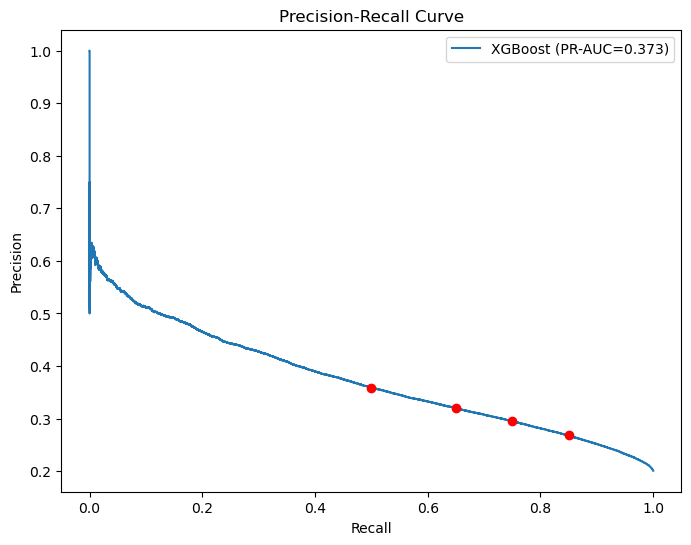

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"XGBoost (PR-AUC={average_precision_score(Y_test, Y_proba_xgb):.3f})")
plt.scatter([0.5, 0.65, 0.75, 0.85], [0.359, 0.320, 0.295, 0.268], color="red", zorder=5)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [37]:
feature_names = best_xgb_model.named_steps["preprocessor"].get_feature_names_out()
print(f"Number of features after preprocessing: {len(feature_names)}")
print(feature_names[:20])  # sanity check

Number of features after preprocessing: 15
['num__loan_amnt' 'num__term' 'num__int_rate' 'num__installment'
 'num__annual_inc' 'num__dti' 'num__open_acc' 'num__revol_util'
 'num__credit_history_years' 'cat__grade_B' 'cat__grade_C' 'cat__grade_D'
 'cat__grade_E' 'cat__grade_F' 'cat__grade_G']


In [38]:
xgb_classifier = best_xgb_model.named_steps["classifier"]
importances = xgb_classifier.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(importance_df.head(15))

                      feature  importance
1                   num__term    0.278997
2               num__int_rate    0.157594
10               cat__grade_C    0.097945
11               cat__grade_D    0.096952
12               cat__grade_E    0.090164
9                cat__grade_B    0.087347
14               cat__grade_G    0.060391
13               cat__grade_F    0.048428
4             num__annual_inc    0.016020
5                    num__dti    0.015711
3            num__installment    0.012033
0              num__loan_amnt    0.011466
8   num__credit_history_years    0.009719
7             num__revol_util    0.008788
6               num__open_acc    0.008446


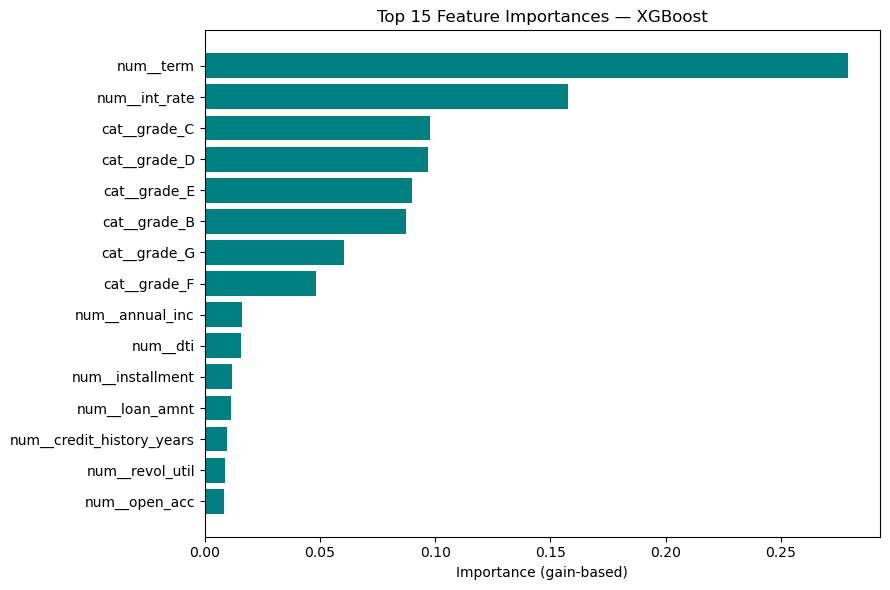

In [39]:
import matplotlib.pyplot as plt

top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1], color="teal")
plt.xlabel("Importance (gain-based)")
plt.title(f"Top {top_n} Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

In [40]:
xgb_booster = xgb_classifier.get_booster()

for importance_type in ["gain", "weight", "cover"]:
    scores = xgb_booster.get_score(importance_type=importance_type)
    print(f"\nTop 5 by {importance_type}:")
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
    for feat, score in sorted_scores:
        print(f"  {feat}: {score:.2f}")


Top 5 by gain:
  f1: 552.28
  f2: 311.96
  f10: 193.88
  f11: 191.92
  f12: 178.48

Top 5 by weight:
  f7: 4676.00
  f5: 4675.00
  f2: 4640.00
  f4: 4347.00
  f8: 4338.00

Top 5 by cover:
  f14: 56258.61
  f1: 47471.63
  f2: 38400.41
  f13: 31703.20
  f9: 28522.38


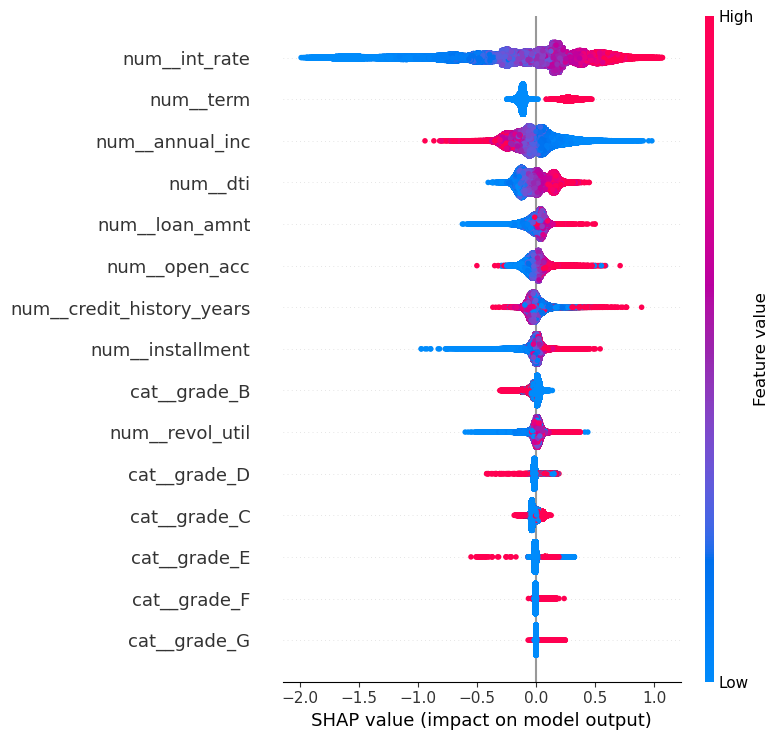

In [42]:
# pip install shap
import shap

explainer = shap.TreeExplainer(xgb_classifier)
X_test_transformed = best_xgb_model.named_steps["preprocessor"].transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

In [46]:
import joblib
model_metadata = {
    "model": best_xgb_model,
    "threshold": 0.502,
    "target_recall": 0.67
}
joblib.dump(model_metadata, "XGB_default_pred_model.pkl")

['XGB_default_pred_model.pkl']